In [1]:
import pandas as pd

df = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1)
df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.10,-.22,-.19,-.11,-.15,-.24,-.23,-.19,-.18,***,***,-0.12,-.17,-.21
1,1881,-0.20,-0.16,0.02,0.04,0.06,-.19,.01,-.04,-.16,-.22,-.19,-.07,-.09,-.10,-.18,0.04,-.07,-.19
2,1882,0.15,0.13,0.04,-0.16,-0.14,-.23,-.17,-.08,-.15,-.24,-.17,-.37,-.11,-.09,.07,-0.09,-.16,-.19
3,1883,-0.30,-0.37,-0.13,-0.18,-0.18,-.07,-.08,-.14,-.22,-.11,-.24,-.12,-.18,-.20,-.34,-0.16,-.10,-.19
4,1884,-0.13,-0.08,-0.37,-0.40,-0.34,-.35,-.31,-.28,-.27,-.25,-.34,-.31,-.29,-.27,-.11,-0.37,-.31,-.29


In [5]:
df.shape

(147, 19)

In [6]:
df.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON'],
      dtype='object')

In [7]:
df.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun      object
Jul      object
Aug      object
Sep      object
Oct      object
Nov      object
Dec      object
J-D      object
D-N      object
DJF      object
MAM     float64
JJA      object
SON      object
dtype: object

In [8]:
df.isnull().sum()

Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     0
Jul     0
Aug     0
Sep     0
Oct     0
Nov     0
Dec     0
J-D     0
D-N     0
DJF     0
MAM     0
JJA     0
SON     0
dtype: int64

In [9]:
df = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1, na_values=["***"])
df.dtypes

Year      int64
Jan     float64
Feb     float64
Mar     float64
Apr     float64
May     float64
Jun     float64
Jul     float64
Aug     float64
Sep     float64
Oct     float64
Nov     float64
Dec     float64
J-D     float64
D-N     float64
DJF     float64
MAM     float64
JJA     float64
SON     float64
dtype: object

In [10]:
df.isnull().sum()

Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     1
Jul     1
Aug     1
Sep     1
Oct     1
Nov     1
Dec     1
J-D     1
D-N     2
DJF     1
MAM     0
JJA     1
SON     1
dtype: int64

In [11]:
# keep only the columns we need
df = df[["Year", "J-D"]]
df.head()

,Year,J-D
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


In [12]:
# drop the one row where J-D is missing
df = df.dropna(subset=["J-D"])
df.shape

(146, 2)

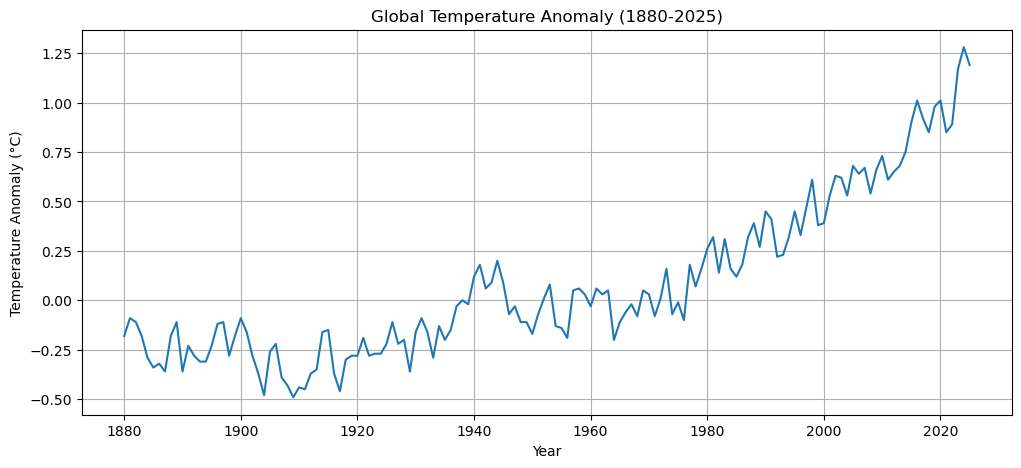

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["Year"], df["J-D"])
plt.title("Global Temperature Anomaly (1880-2025)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.show()

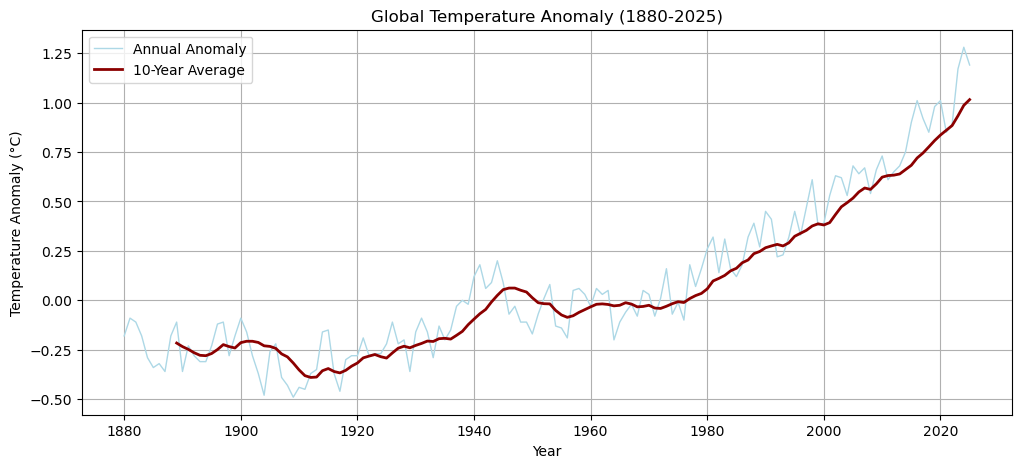

In [14]:
plt.figure(figsize=(12, 5))

# original noisy line
plt.plot(df["Year"], df["J-D"], color="lightblue", linewidth=1, label="Annual Anomaly")

# smoothed line
df["smoothed"] = df["J-D"].rolling(window=10).mean()
plt.plot(df["Year"], df["smoothed"], color="darkred", linewidth=2, label="10-Year Average")

plt.title("Global Temperature Anomaly (1880-2025)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(True)
plt.show()

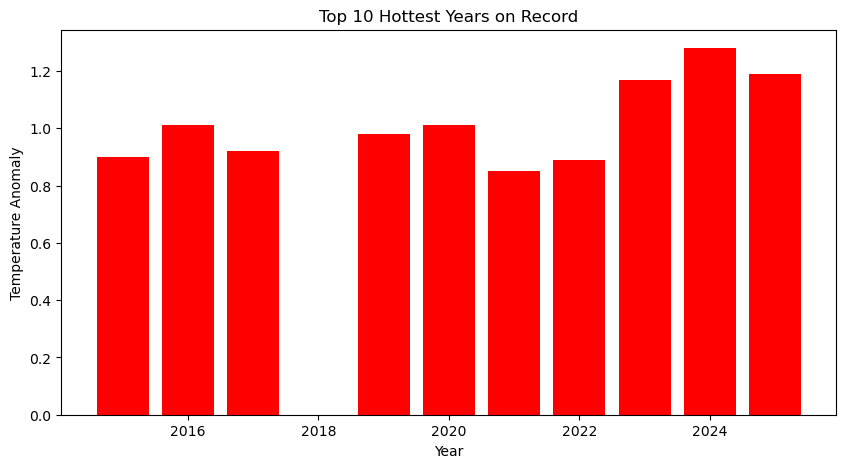

In [16]:
# step 1 - get top 10 hottest years
top10 = df.sort_values("J-D", ascending=False).head(10)
top10 = top10.sort_values("J-D", ascending=False)
# step 2 - plot
plt.figure(figsize=(10, 5))
plt.bar(top10["Year"], top10["J-D"], color="red")
plt.title("Top 10 Hottest Years on Record")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.show()

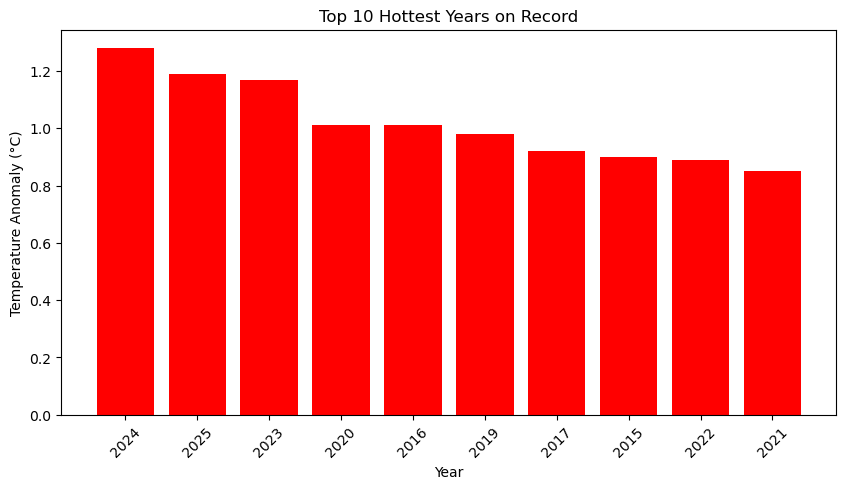

In [17]:
top10 = df.sort_values("J-D", ascending=False).head(10)
top10 = top10.sort_values("J-D", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(top10["Year"].astype(str), top10["J-D"], color="red")
plt.title("Top 10 Hottest Years on Record")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.xticks(rotation=45)
plt.show()

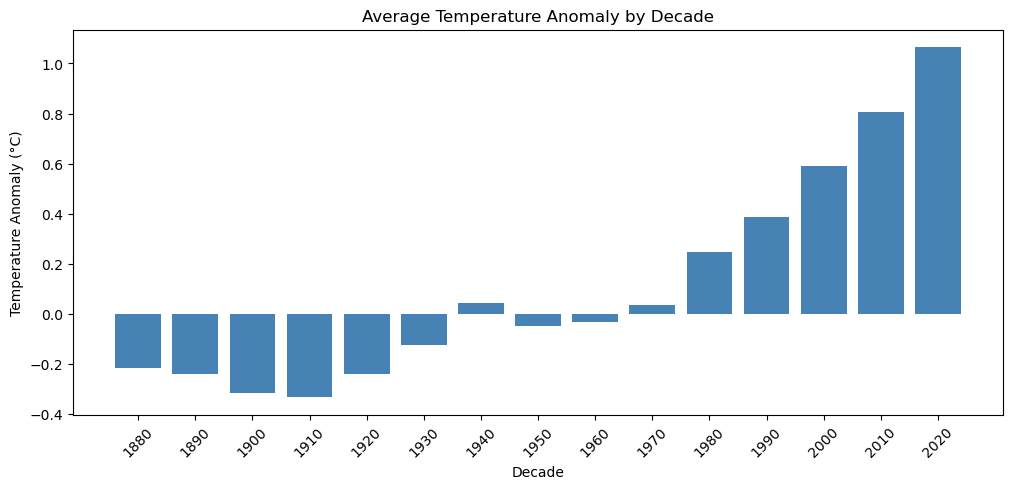

In [18]:
df["decade"] = (df["Year"] // 10) * 10
decadal = df.groupby("decade")["J-D"].mean()

plt.figure(figsize=(12, 5))
plt.bar(decadal.index.astype(str), decadal.values, color="steelblue")
plt.title("Average Temperature Anomaly by Decade")
plt.xlabel("Decade")
plt.ylabel("Temperature Anomaly (°C)")
plt.xticks(rotation=45)
plt.show()

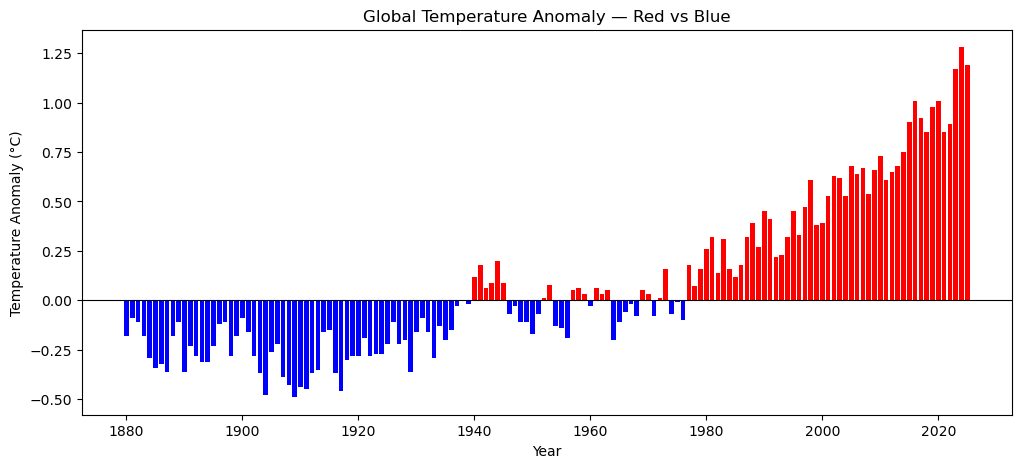

In [19]:
plt.figure(figsize=(12, 5))

colors = ["red" if val > 0 else "blue" for val in df["J-D"]]

plt.bar(df["Year"], df["J-D"], color=colors)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.title("Global Temperature Anomaly — Red vs Blue")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.show()

In [5]:
import pandas as pd

df = pd.read_csv("GLB.Ts+dSST.csv", skiprows=1, na_values=["***"])
df = df[["Year", "J-D"]]
df = df.dropna(subset=["J-D"])

In [7]:
co2 = pd.read_csv("co2_annmean_mlo.csv", comment="#")
co2 = co2.rename(columns={"year": "Year", "mean": "co2"})
co2.head()

,Year,co2,unc
0,1959,315.98,0.12
1,1960,316.91,0.12
2,1961,317.64,0.12
3,1962,318.45,0.12
4,1963,318.99,0.12


In [8]:
merged = pd.merge(df, co2[["Year", "co2"]], on="Year")
merged.head()

,Year,J-D,co2
0,1959,0.03,315.98
1,1960,-0.03,316.91
2,1961,0.06,317.64
3,1962,0.03,318.45
4,1963,0.05,318.99


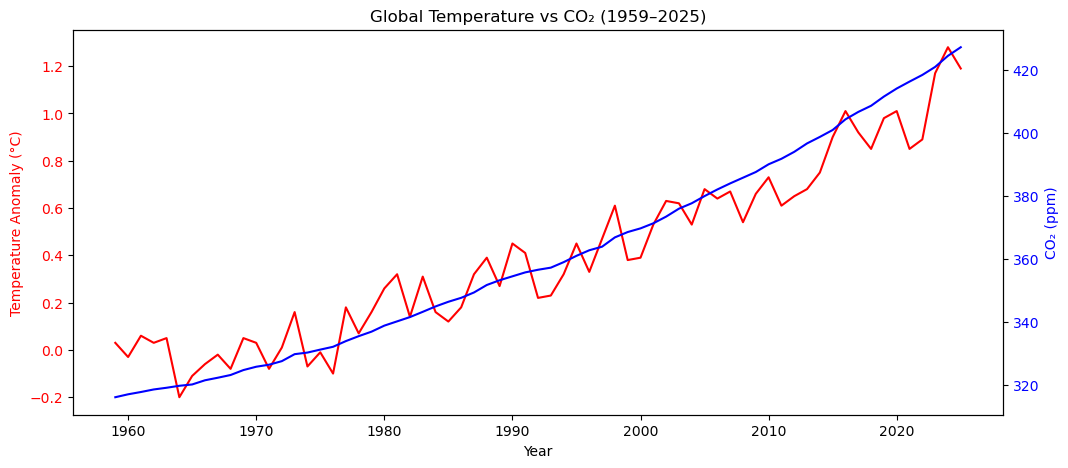

In [11]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(12, 5))

# left axis — temperature
ax1.plot(merged["Year"], merged["J-D"], color="red", label="Temperature Anomaly")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature Anomaly (°C)", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# right axis — CO₂
ax2 = ax1.twinx()
ax2.plot(merged["Year"], merged["co2"], color="blue", label="CO₂ (ppm)")
ax2.set_ylabel("CO₂ (ppm)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Global Temperature vs CO₂ (1959–2025)")
plt.show()